# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [ ]:
#Exercicio 2:
#Importação pacotes
import pandas as pd
import os
from Bio import SeqIO

#Lista dos aminoácidos
aminoacidos = list("ARNDCQEGHILKMFPSTWYV")
#Chamando os arquivos fasta
pasta_fasta = "."

dados = []

for arquivo in os.listdir(pasta_fasta):
    if arquivo.endswith(".fasta"):
        
        nome_gene = arquivo.replace(".fasta", "")
        caminho = arquivo 
        
        print("Lendo:", caminho)
        
        seq = ""
        for record in SeqIO.parse(caminho, "fasta"):
            seq = str(record.seq)
        
        contagem = {}
        for aa in aminoacidos:
            contagem[aa] = seq.count(aa)
        
        contagem["gene"] = nome_gene
        dados.append(contagem)

#Exercicio 1:
df_freq = pd.DataFrame(dados).set_index("gene")
print(df_freq)
df_freq.to_csv("frequencia_aminoacidos.csv")
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
print(df_freq.head())
def tendencia_central(vetor):
    media = vetor.mean()
    mediana = vetor.median()
    if not vetor.mode().empty:
        moda = vetor.mode()[0]
    else:
        moda = None
    return media, mediana, moda
serina = df_freq["S"]
media, mediana, moda = tendencia_central(serina)

print("Serina (todos os genes):")
print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)
terceiro_gene = df_freq.iloc[2]  #loc. do terceiro gene

serina_terceiro = terceiro_gene["S"]
media = serina_terceiro
mediana = serina_terceiro
moda = serina_terceiro

print("Serina (terceiro gene):")
print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Lendo: atpsf1a.fasta
Lendo: Hur.fasta
Lendo: ifna.fasta
Lendo: isg15.fasta
Lendo: tnfa.fasta
          A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T  \
gene                                                                          
atpsf1a  58  38  16  29   2  25  31  51   7  39  53  30  12  16  18  39  27   
Hur      23  20  23  16   3  12  15  29   8  19  22  18  10  18  12  28  16   
ifna     11  10   4   8   6  12  14   6   3   8  27  11   6  11   5  18  11   
isg15     7   8   4   7   1  12   9  18   3   3  24   8   4   5   8  15   9   
tnfa     50  56  40  30  40  39  57  45  30  27  64  46  20  34  56  53  47   

         W   Y   V  
gene                
atpsf1a  0  16  46  
Hur      2  10  22  
ifna     2   5  10  
isg15    2   2  16  
tnfa     9  18  29  
          A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T  \
gene                                                                          
atpsf1a  58  38  16  29   2  25  31  51   7  39 

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [ ]:
#Importação pacote
import pandas as pd

#CSV 
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
print(df_freq.head())
#Definindo amplitude
def amplitude(vetor):
    return vetor.max() - vetor.min()
#Isoleucina
isoleucina = df_freq["I"]
amp_I = amplitude(isoleucina)
print("Amplitude da Isoleucina:", amp_I)
#Ultimo gene
ultimo_gene = df_freq.iloc[-1]
amp_ultimo = amplitude(ultimo_gene)
print("Amplitude do último gene:", amp_ultimo)

          A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T  \
gene                                                                          
atpsf1a  58  38  16  29   2  25  31  51   7  39  53  30  12  16  18  39  27   
Hur      23  20  23  16   3  12  15  29   8  19  22  18  10  18  12  28  16   
ifna     11  10   4   8   6  12  14   6   3   8  27  11   6  11   5  18  11   
isg15     7   8   4   7   1  12   9  18   3   3  24   8   4   5   8  15   9   
tnfa     50  56  40  30  40  39  57  45  30  27  64  46  20  34  56  53  47   

         W   Y   V  
gene                
atpsf1a  0  16  46  
Hur      2  10  22  
ifna     2   5  10  
isg15    2   2  16  
tnfa     9  18  29  

Amplitude da Isoleucina: 36

Amplitude do último gene: 55


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [4]:
#Importação pacote:
import pandas as pd
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
print(df_freq.head())
#Quartis
def quartis(vetor):
    Q1 = vetor.quantile(0.25)
    Q2 = vetor.quantile(0.50)  # mediana
    Q3 = vetor.quantile(0.75)
    
    return Q1, Q2, Q3
#Metionina
metionina = df_freq["M"]
Q1_M, Q2_M, Q3_M = quartis(metionina)
print("Metionina (M):")
print("Q1:", Q1_M)
print("Q2 (mediana):", Q2_M)
print("Q3:", Q3_M)
#Primeiro gene
primeiro_gene = df_freq.iloc[0]
Q1_g, Q2_g, Q3_g = quartis(primeiro_gene)
print("Primeiro gene:")
print("Q1:", Q1_g)
print("Q2 (mediana):", Q2_g)
print("Q3:", Q3_g)

          A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T  \
gene                                                                          
atpsf1a  58  38  16  29   2  25  31  51   7  39  53  30  12  16  18  39  27   
Hur      23  20  23  16   3  12  15  29   8  19  22  18  10  18  12  28  16   
ifna     11  10   4   8   6  12  14   6   3   8  27  11   6  11   5  18  11   
isg15     7   8   4   7   1  12   9  18   3   3  24   8   4   5   8  15   9   
tnfa     50  56  40  30  40  39  57  45  30  27  64  46  20  34  56  53  47   

         W   Y   V  
gene                
atpsf1a  0  16  46  
Hur      2  10  22  
ifna     2   5  10  
isg15    2   2  16  
tnfa     9  18  29  
Metionina (M):
Q1: 6.0
Q2 (mediana): 10.0
Q3: 12.0
Primeiro gene:
Q1: 16.0
Q2 (mediana): 28.0
Q3: 39.0


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

Intervalo interquartil do Ácido Glutâmico (E): 17.0

Intervalo interquartil do penúltimo gene: 6.0


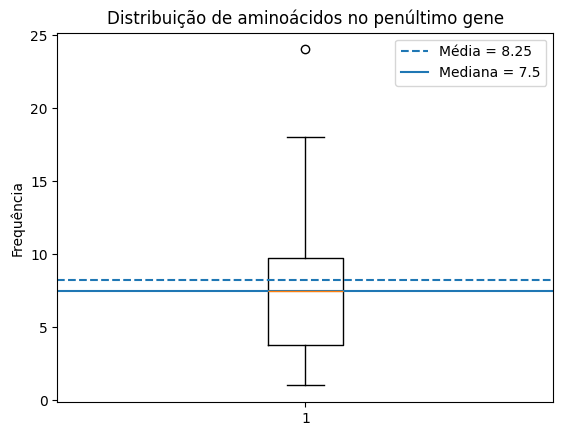

In [ ]:
#Importação pacote
import pandas as pd
import matplotlib.pyplot as plt
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#Interquartil
def intervalo_interquartil(vetor):
    Q1 = vetor.quantile(0.25)
    Q3 = vetor.quantile(0.75)
    return Q3 - Q1
#Ácido glutamico
glutamico = df_freq["E"]
iqr_E = intervalo_interquartil(glutamico)
print("Intervalo interquartil do Ácido Glutâmico (E):", iqr_E)
#Penultimo gene
penultimo_gene = df_freq.iloc[-2]
iqr_gene = intervalo_interquartil(penultimo_gene)
print("Intervalo interquartil do penúltimo gene:", iqr_gene)
#Gráfico
#Cálculos
media = penultimo_gene.mean()
mediana = penultimo_gene.median()
plt.figure()
plt.boxplot(penultimo_gene)
plt.axhline(media, linestyle='--', label=f"Média = {media:.2f}")
plt.axhline(mediana, linestyle='-', label=f"Mediana = {mediana}")
plt.title("Distribuição de aminoácidos no penúltimo gene")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [ ]:
#Importação pacote
import pandas as pd
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#Variãncia
def variancia(vetor):
    return vetor.var(ddof=1)
#Prolina
prolina = df_freq["P"]
var_P = variancia(prolina)
print("Variância da Prolina (P):", var_P)
#Terceiro gene
terceiro_gene = df_freq.iloc[2]
var_gene = variancia(terceiro_gene)
print("Variância do terceiro gene:", var_gene)

Variância da Prolina (P): 433.20000000000005

Variância do terceiro gene: 32.88421052631579


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [ ]:
#Importação pacote
import pandas as pd
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#DP
def desvio_padrao(vetor):
    return vetor.std(ddof=1)
#Triptofano
triptofano = df_freq["W"]
dp_W = desvio_padrao(triptofano)
print("Desvio padrão do Triptofano (W):", dp_W)
#último gene
ultimo_gene = df_freq.iloc[-1]
dp_gene = desvio_padrao(ultimo_gene)
print("Desvio padrão do último gene:", dp_gene)

Desvio padrão do Triptofano (W): 3.4641016151377544

Desvio padrão do último gene: 14.730919862656235


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [3]:
#Importação pacote
import pandas as pd
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#CV
def coef_variacao(vetor):
    media = vetor.mean()
    desvio = vetor.std(ddof=1)
    if media != 0:
        return desvio / media
    else:
        return None  # evita divisão por zero
#Leucina
leucina = df_freq["L"]
cv_L = coef_variacao(leucina)
print("Coeficiente de variação da Leucina (L):", cv_L)
#Gene 1
gene_1 = df_freq.iloc[1]
cv_gene = coef_variacao(gene_1)
print("Coeficiente de variação do gene índice 1:", cv_gene)

Coeficiente de variação da Leucina (L): 0.5051672058013806
Coeficiente de variação do gene índice 1: 0.45567759218717035


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [1]:
#Importação pacote
import pandas as pd
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#Medida resumo 
def medidas_resumo(vetor):
    
    resumo = {
        "média": vetor.mean(),
        "mediana": vetor.median(),
        "moda": vetor.mode()[0] if not vetor.mode().empty else None,
        "mínimo": vetor.min(),
        "máximo": vetor.max(),
        "amplitude": vetor.max() - vetor.min(),
        "variância": vetor.var(ddof=1),
        "desvio_padrão": vetor.std(ddof=1),
        "Q1": vetor.quantile(0.25),
        "Q2 (mediana)": vetor.quantile(0.50),
        "Q3": vetor.quantile(0.75),
        "IQR": vetor.quantile(0.75) - vetor.quantile(0.25),
        "coef_variação": vetor.std(ddof=1) / vetor.mean() if vetor.mean() != 0 else None
    }
    
    return resumo
#Serina
resumo_serina = medidas_resumo(df_freq["S"])
print("Resumo - Serina:")
for k, v in resumo_serina.items():
    print(f"{k}: {v}")

#Quinto gene
resumo_gene = medidas_resumo(df_freq.iloc[4])
print("Resumo - Quinto gene:")
for k, v in resumo_gene.items():
    print(f"{k}: {v}")

Resumo - Serina:
média: 30.6
mediana: 28.0
moda: 15
mínimo: 15
máximo: 53
amplitude: 38
variância: 245.3
desvio_padrão: 15.662056059151366
Q1: 18.0
Q2 (mediana): 28.0
Q3: 39.0
IQR: 21.0
coef_variação: 0.5118318973578878
Resumo - Quinto gene:
média: 39.5
mediana: 40.0
moda: 30
mínimo: 9
máximo: 64
amplitude: 55
variância: 217.0
desvio_padrão: 14.730919862656235
Q1: 29.75
Q2 (mediana): 40.0
Q3: 50.75
IQR: 21.0
coef_variação: 0.37293468006724645


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

Coeficiente de variação por gene:

atpsf1a: 0.6114
Hur: 0.4557
ifna: 0.6101
isg15: 0.7356
tnfa: 0.3729

Gene com maior CV: isg15


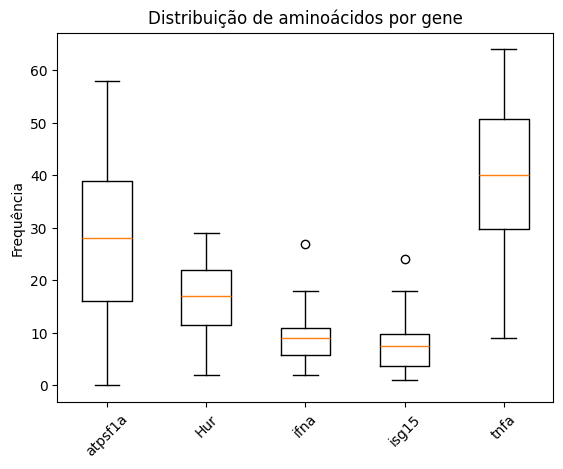

In [ ]:
#Importação pacote
import pandas as pd
import matplotlib.pyplot as plt
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#CV
def coef_variacao(vetor):
    media = vetor.mean()
    desvio = vetor.std(ddof=1)
    
    if media != 0:
        return desvio / media
    else:
        return None
#Gene com maior CV
def gene_maior_cv(df):
    cvs = {}
    for gene in df.index:
        vetor = df.loc[gene]
        cvs[gene] = coef_variacao(vetor)
    maior_gene = max(cvs, key=cvs.get)
    return maior_gene, cvs

gene, cvs = gene_maior_cv(df_freq)
print("Coeficiente de variação por gene:")
for g, v in cvs.items():
    print(f"{g}: {v:.4f}")
print("Gene com maior CV:", gene)
#Doxplot
plt.figure()
plt.boxplot(df_freq.T)
plt.title("Distribuição de aminoácidos por gene")
plt.ylabel("Frequência")
plt.xticks(range(1, len(df_freq.index)+1), df_freq.index, rotation=45)
plt.show()

R: Os resultados não apresentam concordância direta. Embora o gene isg15 apresente o maior CV, indicando maior variabilidade relativa, o gráfico de boxplot sugere maior dispersão absoluta para o gene tnfa. Essa diferença ocorre porque o CV considera a razão entre o desvio padrão e a média, enquanto o gráfico de boxplot reflete a dispersão absoluta dos dados. Assim, genes com valores médios maiores podem apresentar maior amplitude visual, mas menor variabilidade relativa.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

Coeficiente de variação por aminoácido:

A: 0.7731
R: 0.7715
N: 0.8636
D: 0.6149
C: 1.6012
Q: 0.6010
E: 0.7778
G: 0.6248
H: 1.1079
I: 0.7551
L: 0.5052
K: 0.6895
M: 0.5989
F: 0.6458
P: 1.0512
S: 0.5118
T: 0.7100
W: 1.1547
Y: 0.6736
V: 0.5644

Aminoácido com maior CV: C


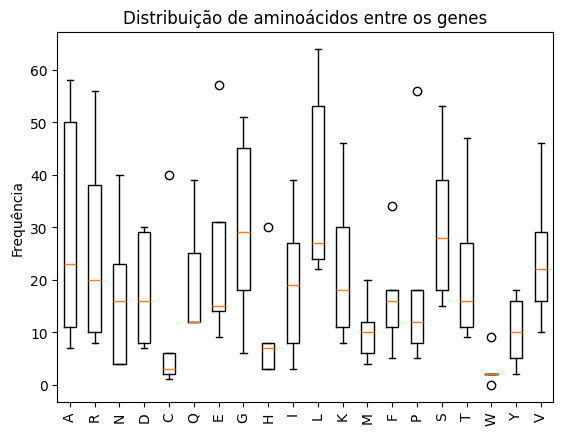

In [ ]:
#Importação pacote
import pandas as pd
import matplotlib.pyplot as plt
#CSV
df_freq = pd.read_csv("frequencia_aminoacidos.csv", index_col="gene")
#CV
def coef_variacao(vetor):
    media = vetor.mean()
    desvio = vetor.std(ddof=1)
    if media != 0:
        return desvio / media
    else:
        return None
#AA - CV maior
def aa_maior_cv(df):
    cvs = {}
    for aa in df.columns:
        cvs[aa] = coef_variacao(df[aa])
    maior_aa = max(cvs, key=cvs.get)
    return maior_aa, cvs

aa, cvs = aa_maior_cv(df_freq)
print("Coeficiente de variação por aminoácido:")
for k, v in cvs.items():
    print(f"{k}: {v:.4f}")
print("Aminoácido com maior CV:", aa)
#Gráfico
plt.figure()
plt.boxplot(df_freq)
plt.title("Distribuição de aminoácidos entre os genes")
plt.ylabel("Frequência")
plt.xticks(range(1, len(df_freq.columns)+1), df_freq.columns, rotation=90)
plt.show()

R: Os resultados não concordam diretamente, pois o CV mede a variabilidade relativa (influenciada pela média), enquanto o boxplot representa a dispersão absoluta. Como a cisteína apresenta média baixa, pequenas variações resultam em alto CV, sem necessariamente apresentar grande dispersão visual.